# EDA Assignment - Bike Details Dataset



In [14]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline
%matplotlib inline

# Load dataset
# Replace the path below with your dataset path if needed
df = pd.read_csv('BIKE DETAILS.csv')

# Display first few rows
df.head()


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


## Question 1

In [4]:
# Question 1: Read the Bike Details dataset into a Pandas DataFrame and display its first 10 rows.

print("First 10 Rows:")
display(df.head(10))

print("\nShape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


First 10 Rows:


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
5,Honda CB Twister,18000,2010,Individual,1st owner,60000,53857.0
6,Honda CB Hornet 160R,78500,2018,Individual,1st owner,17000,87719.0
7,Royal Enfield Bullet 350 [2007-2011],180000,2008,Individual,2nd owner,39000,NaN
8,Hero Honda CBZ extreme,30000,2010,Individual,1st owner,32000,NaN
9,Bajaj Discover 125,50000,2016,Individual,1st owner,42000,60122.0



Shape of Dataset: (1061, 7)

Column Names:
['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven', 'ex_showroom_price']


## Question 2

In [5]:
# Question 2: Check for missing values in all columns and describe your approach for handling them.

print("Missing Values in Each Column:")
print(df.isnull().sum())

# Handling missing values
# Example approach:
# Numerical columns -> fill with median
# Categorical columns -> fill with mode

for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Handling:")
print(df.isnull().sum())


Missing Values in Each Column:
name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

Missing Values After Handling:
name                 0
selling_price        0
year                 0
seller_type          0
owner                0
km_driven            0
ex_showroom_price    0
dtype: int64


/tmp/ipykernel_5303/3178148639.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_5303/3178148639.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

## Question 3

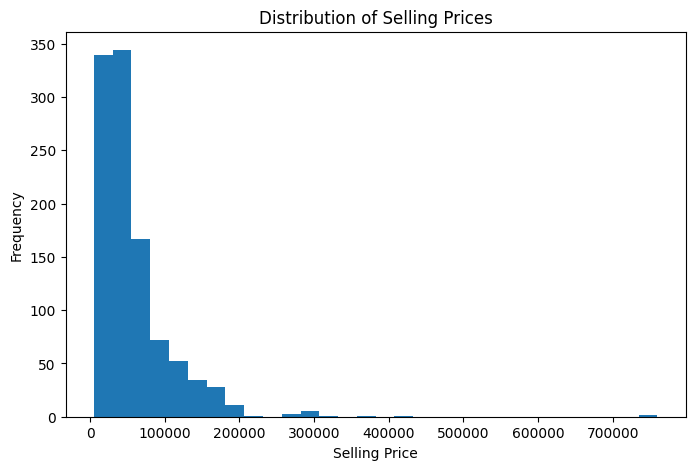

Observation: Most bikes are concentrated in lower and medium price ranges.


In [6]:
# Question 3: Plot the distribution of selling prices using a histogram and describe the overall trend.

plt.figure(figsize=(8,5))
plt.hist(df['selling_price'], bins=30)
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.title('Distribution of Selling Prices')
plt.show()

print("Observation: Most bikes are concentrated in lower and medium price ranges.")


## Question 4

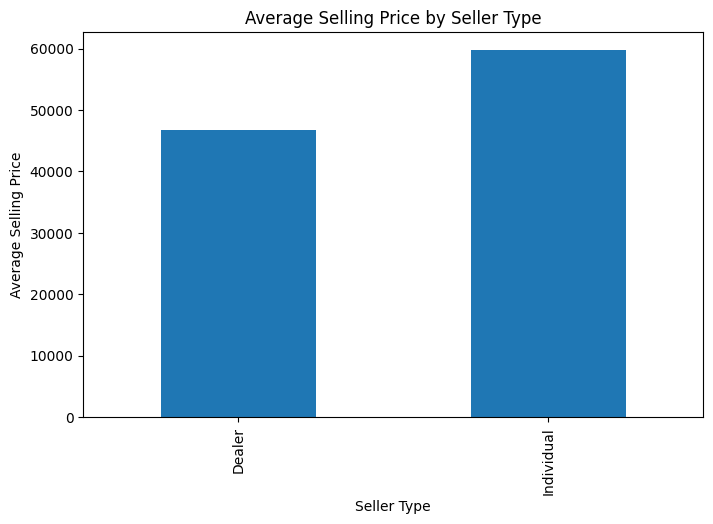

Observation: Seller types with premium bikes tend to have higher average selling prices.


In [7]:
# Question 4: Create a bar plot to visualize the average selling price for each seller_type and write one observation.

avg_price = df.groupby('seller_type')['selling_price'].mean()

plt.figure(figsize=(8,5))
avg_price.plot(kind='bar')
plt.xlabel('Seller Type')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Seller Type')
plt.show()

print("Observation: Seller types with premium bikes tend to have higher average selling prices.")


## Question 5

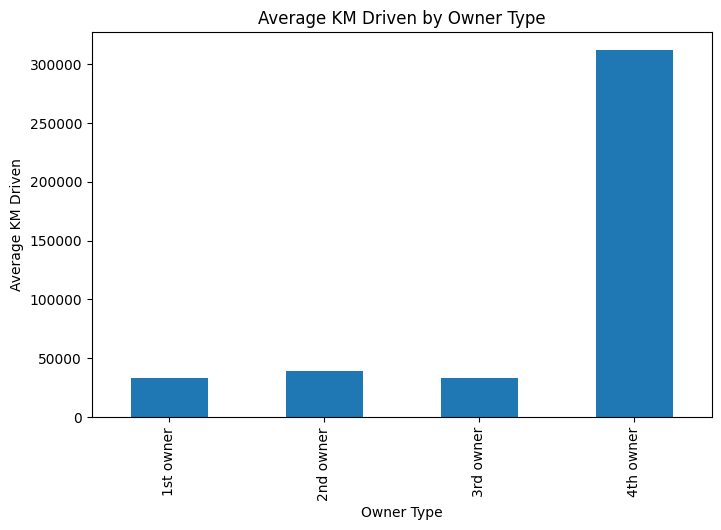

owner
1st owner     32816.583333
2nd owner     39288.991870
3rd owner     33292.181818
4th owner    311500.000000
Name: km_driven, dtype: float64


In [8]:
# Question 5: Compute the average km_driven for each ownership type (1st owner, 2nd owner, etc.), and present the result as a bar plot.

avg_km = df.groupby('owner')['km_driven'].mean()

plt.figure(figsize=(8,5))
avg_km.plot(kind='bar')
plt.xlabel('Owner Type')
plt.ylabel('Average KM Driven')
plt.title('Average KM Driven by Owner Type')
plt.show()

print(avg_km)


## Question 6

In [9]:
# Question 6: Use the IQR method to detect and remove outliers from the km_driven column. Show before-and-after summary statistics.

print("Before Removing Outliers:")
print(df['km_driven'].describe())

Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['km_driven'] >= lower_bound) & (df['km_driven'] <= upper_bound)]

print("\nAfter Removing Outliers:")
print(df_no_outliers['km_driven'].describe())


Before Removing Outliers:
count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64

After Removing Outliers:
count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64


## Question 7

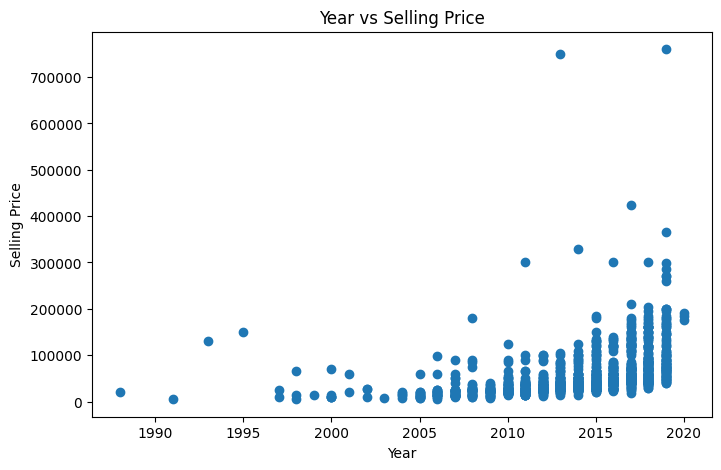

Observation: Newer bikes generally have higher selling prices.


In [10]:
# Question 7: Create a scatter plot of year vs. selling_price to explore the relationship between a bike's age and its price.

plt.figure(figsize=(8,5))
plt.scatter(df['year'], df['selling_price'])
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.title('Year vs Selling Price')
plt.show()

print("Observation: Newer bikes generally have higher selling prices.")


## Question 8

In [11]:
# Question 8: Convert the seller_type column into numeric format using one-hot encoding. Display the first 5 rows of the resulting DataFrame.

encoded_df = pd.get_dummies(df, columns=['seller_type'])

display(encoded_df.head())


,name,selling_price,year,owner,km_driven,ex_showroom_price,seller_type_Dealer,seller_type_Individual
0,Royal Enfield Classic 350,175000,2019,1st owner,350,72752.5,False,True
1,Honda Dio,45000,2017,1st owner,5650,72752.5,False,True
2,Royal Enfield Classic Gunmetal Grey,150000,2018,1st owner,12000,148114.0,False,True
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,1st owner,23000,89643.0,False,True
4,Yamaha SZ [2013-2014],20000,2011,2nd owner,21000,72752.5,False,True


## Question 9

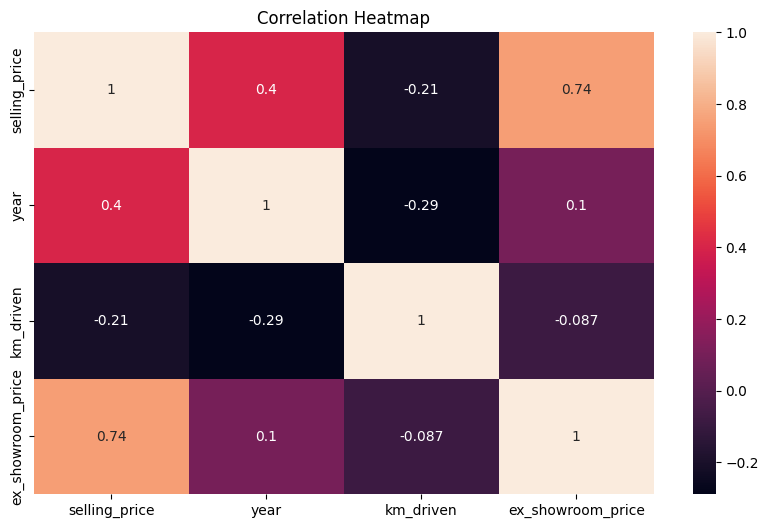

Strong correlations can help identify factors affecting selling price.


In [12]:
# Question 9: Generate a heatmap of the correlation matrix for all numeric columns. What correlations stand out the most?

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Heatmap')
plt.show()

print("Strong correlations can help identify factors affecting selling price.")


## Question 10

In [13]:
# Question 10: Summarize your findings in a brief report:
#● What are the most important factors affecting a bike's selling price?
#● Mention any data cleaning or feature engineering you performed.

summary = '''
Summary of Findings:

1. Selling price is influenced mainly by:
   - Bike year
   - Kilometers driven
   - Ownership type
   - Seller type

2. Data Cleaning Performed:
   - Missing values handled using median/mode
   - Outliers removed using IQR method

3. Feature Engineering:
   - One-hot encoding applied on seller_type column

4. Insights:
   - Newer bikes usually have higher selling prices.
   - Bikes with lower kilometers driven tend to be priced higher.
'''

print(summary)



Summary of Findings:

1. Selling price is influenced mainly by:
   - Bike year
   - Kilometers driven
   - Ownership type
   - Seller type

2. Data Cleaning Performed:
   - Missing values handled using median/mode
   - Outliers removed using IQR method

3. Feature Engineering:
   - One-hot encoding applied on seller_type column

4. Insights:
   - Newer bikes usually have higher selling prices.
   - Bikes with lower kilometers driven tend to be priced higher.

